Advitiya Apurv 24EE10029 Afrin Munshi 24EE10030

In [2]:
import numpy as np
import matplotlib . pyplot as plt
import torch as torch
import torch.nn as nn
from torch.optim import SGD , Adam , AdamW
from torchvision import datasets , transforms


In [3]:
transform = transforms . Compose ([ transforms . ToTensor () , transforms . Normalize ((0.5 ,) ,
(0.5 ,) ) , transforms . Lambda ( lambda x : torch . flatten ( x ) ) ])
train_dataset = datasets . MNIST ('MNIST_data', download = True , train = True ,
transform = transform )
test_dataset = datasets . MNIST ('MNIST_data', download = True , train = False ,
transform = transform )


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.98MB/s]


In [4]:
indices = list ( range (len( train_dataset ) ) )
np.random.shuffle ( indices )
trn_prop = 0.8
trn_split = int( trn_prop * len( train_dataset ) )
trn_indices = indices [ : trn_split ]
vld_indices = indices [ trn_split : ]

trn_sampler = torch . utils . data . SubsetRandomSampler ( trn_indices )
vld_sampler = torch . utils . data . SubsetRandomSampler ( vld_indices )
batch_size = 128
trn_loader = torch . utils . data . DataLoader ( train_dataset , batch_size = batch_size ,
sampler = trn_sampler )
vld_loader = torch . utils . data . DataLoader ( train_dataset , batch_size = batch_size ,
sampler = vld_sampler )
tst_loader = torch . utils . data . DataLoader ( test_dataset , batch_size = batch_size ,
shuffle = False )

print (f'Length of the training dataset:{ len( trn_sampler )}')
print (f'Length of the validation dataset : { len( vld_sampler )}')
print ( f'Length of the test dataset : { len( test_dataset )}')


Length of the training dataset:48000
Length of the validation dataset : 12000
Length of the test dataset : 10000


Shape of image : torch.Size([784])
Shape of label : torch.Size([])
Label of image : 5 


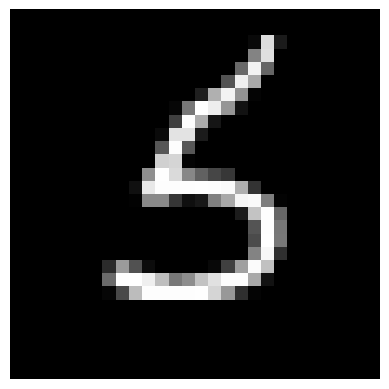

In [6]:
image , label = next ( iter ( trn_loader ) )
print ( f'Shape of image : { image [0]. shape}') # torch . Size ([784])
print ( f'Shape of label : { label [0]. shape }') # torch . Size ([]) : empty array because itis a scalar

print ( f'Label of image : { label [0]} ')

plt . imshow ( image [0]. numpy () . reshape (28 , 28) , cmap = 'gray')
plt . axis ('off')
plt . show ()
plt . close ()


In [7]:
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 392),
            nn.ReLU(),

            nn.Linear(392, 196),
            nn.ReLU(),

            nn.Linear(196, 98),
            nn.ReLU(),

            nn.Linear(98, 49),
            nn.ReLU(),

            nn.Linear(49, 10)
        )

    def forward(self, x):
        return self.model(x)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = Adam(model.parameters(), lr=1e-3)



In [12]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()

    accuracy = correct / len(loader.sampler)
    return total_loss / len(loader), accuracy

In [13]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()

    accuracy = correct / len(loader.sampler)
    return total_loss / len(loader), accuracy

In [ ]:
epochs = 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = train(model, trn_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, vld_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1:
Train Loss: 0.5388, Train Acc: 0.8275
Val Loss: 0.2526, Val Acc: 0.9225
Epoch 2:
Train Loss: 0.1948, Train Acc: 0.9408
Val Loss: 0.1576, Val Acc: 0.9512
Epoch 3:
Train Loss: 0.1352, Train Acc: 0.9588
Val Loss: 0.1421, Val Acc: 0.9558
Epoch 4:
Train Loss: 0.1098, Train Acc: 0.9658
Val Loss: 0.1251, Val Acc: 0.9627
Epoch 5:
Train Loss: 0.0881, Train Acc: 0.9720
Val Loss: 0.1322, Val Acc: 0.9592
Epoch 6:
Train Loss: 0.0782, Train Acc: 0.9754
Val Loss: 0.1172, Val Acc: 0.9637
Epoch 7:
Train Loss: 0.0638, Train Acc: 0.9802
Val Loss: 0.0967, Val Acc: 0.9712
Epoch 8:
Train Loss: 0.0578, Train Acc: 0.9814
Val Loss: 0.1035, Val Acc: 0.9696
Epoch 9:
Train Loss: 0.0533, Train Acc: 0.9824
Val Loss: 0.0909, Val Acc: 0.9740
Epoch 10:
Train Loss: 0.0503, Train Acc: 0.9836
Val Loss: 0.0960, Val Acc: 0.9743
Epoch 11:
Train Loss: 0.0433, Train Acc: 0.9856
Val Loss: 0.1062, Val Acc: 0.9720
Epoch 12:
Train Loss: 0.0376, Train Acc: 0.9875
Val Loss: 0.1074, Val Acc: 0.9732
Epoch 13:
Train Loss: 0.0

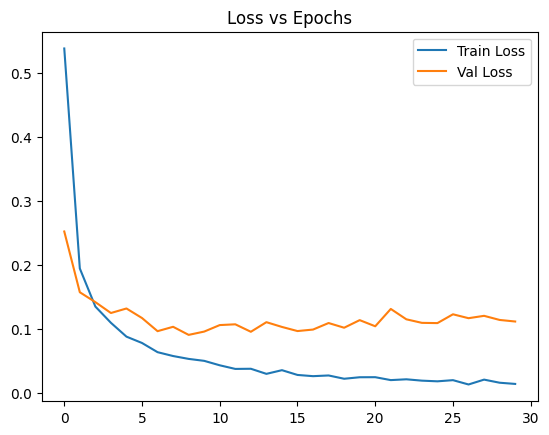

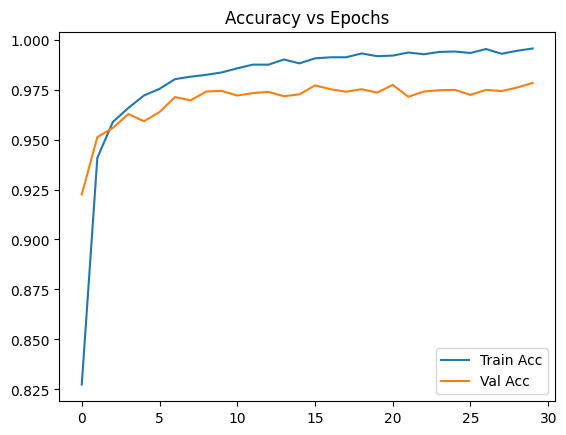

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

In [ ]:
test_loss, test_acc = evaluate(model, tst_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9790


In [ ]:
model = FCNN().to(device)
optimizer = SGD(model.parameters(), lr=1e-3)

# or
#optimizer = SGD(model.parameters(), lr=1e-3, momentum=0.9)
# or
#optimizer = Adam(model.parameters(), lr=1e-3)
# or
#optimizer = AdamW(model.parameters(), lr=1e-3)

In [ ]:
epochs = 50

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = train(model, trn_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, vld_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1:
Train Loss: 2.3021, Train Acc: 0.1398
Val Loss: 2.3004, Val Acc: 0.1570
Epoch 2:
Train Loss: 2.3000, Train Acc: 0.1377
Val Loss: 2.2983, Val Acc: 0.1179
Epoch 3:
Train Loss: 2.2979, Train Acc: 0.1155
Val Loss: 2.2962, Val Acc: 0.1119
Epoch 4:
Train Loss: 2.2956, Train Acc: 0.1128
Val Loss: 2.2939, Val Acc: 0.1115
Epoch 5:
Train Loss: 2.2931, Train Acc: 0.1126
Val Loss: 2.2913, Val Acc: 0.1115
Epoch 6:
Train Loss: 2.2903, Train Acc: 0.1126
Val Loss: 2.2883, Val Acc: 0.1115
Epoch 7:
Train Loss: 2.2871, Train Acc: 0.1126
Val Loss: 2.2850, Val Acc: 0.1117
Epoch 8:
Train Loss: 2.2835, Train Acc: 0.1179
Val Loss: 2.2812, Val Acc: 0.1282
Epoch 9:
Train Loss: 2.2794, Train Acc: 0.1444
Val Loss: 2.2768, Val Acc: 0.1572
Epoch 10:
Train Loss: 2.2746, Train Acc: 0.1719
Val Loss: 2.2717, Val Acc: 0.1814
Epoch 11:
Train Loss: 2.2690, Train Acc: 0.1929
Val Loss: 2.2656, Val Acc: 0.2041
Epoch 12:
Train Loss: 2.2623, Train Acc: 0.2112
Val Loss: 2.2583, Val Acc: 0.2192
Epoch 13:
Train Loss: 2.2

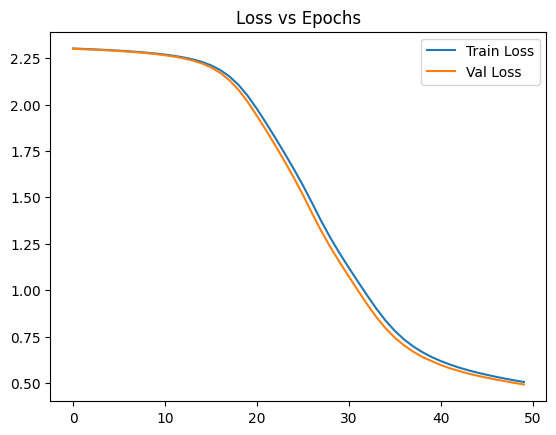

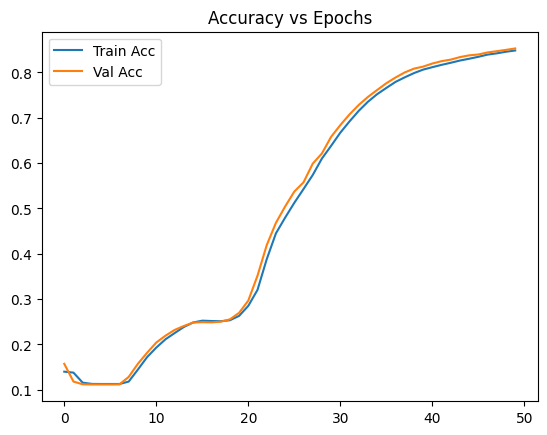

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

In [ ]:
test_loss, test_acc = evaluate(model, tst_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8518


In [ ]:
model = FCNN().to(device)
optimizer = SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [ ]:
epochs = 20

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = train(model, trn_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, vld_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1:
Train Loss: 2.2885, Train Acc: 0.1370
Val Loss: 2.2659, Val Acc: 0.1813
Epoch 2:
Train Loss: 2.1661, Train Acc: 0.2228
Val Loss: 1.9280, Val Acc: 0.2866
Epoch 3:
Train Loss: 1.4551, Train Acc: 0.5524
Val Loss: 1.0143, Val Acc: 0.6975
Epoch 4:
Train Loss: 0.7539, Train Acc: 0.7658
Val Loss: 0.5839, Val Acc: 0.8121
Epoch 5:
Train Loss: 0.5248, Train Acc: 0.8374
Val Loss: 0.4557, Val Acc: 0.8611
Epoch 6:
Train Loss: 0.4378, Train Acc: 0.8690
Val Loss: 0.4140, Val Acc: 0.8721
Epoch 7:
Train Loss: 0.3886, Train Acc: 0.8851
Val Loss: 0.3784, Val Acc: 0.8872
Epoch 8:
Train Loss: 0.3562, Train Acc: 0.8951
Val Loss: 0.3399, Val Acc: 0.8992
Epoch 9:
Train Loss: 0.3304, Train Acc: 0.9031
Val Loss: 0.3146, Val Acc: 0.9079
Epoch 10:
Train Loss: 0.3051, Train Acc: 0.9115
Val Loss: 0.2901, Val Acc: 0.9155
Epoch 11:
Train Loss: 0.2825, Train Acc: 0.9176
Val Loss: 0.2782, Val Acc: 0.9181
Epoch 12:
Train Loss: 0.2601, Train Acc: 0.9245
Val Loss: 0.2517, Val Acc: 0.9269
Epoch 13:
Train Loss: 0.2

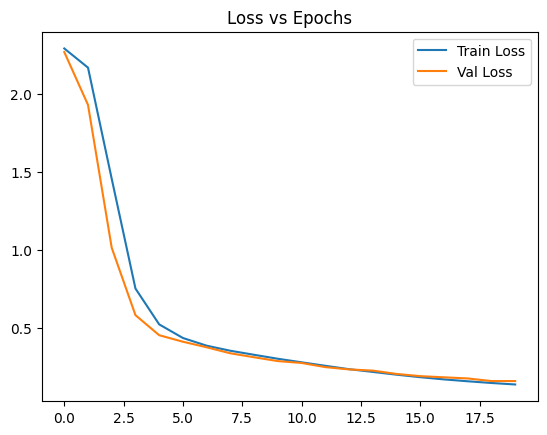

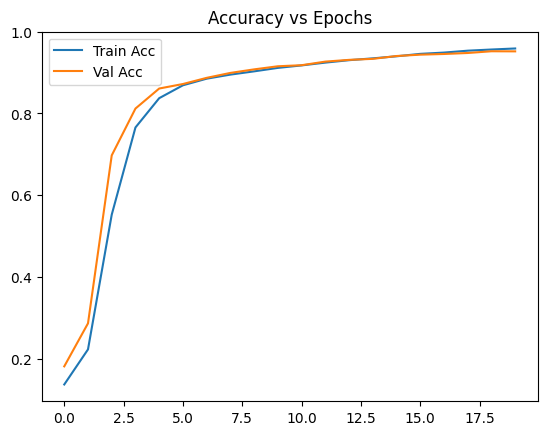

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

In [ ]:
test_loss, test_acc = evaluate(model, tst_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9551


In [ ]:
model = FCNN().to(device)
optimizer = AdamW(model.parameters(), lr=1e-3)

In [ ]:
epochs = 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = train(model, trn_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, vld_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1:
Train Loss: 0.4984, Train Acc: 0.8448
Val Loss: 0.2368, Val Acc: 0.9273
Epoch 2:
Train Loss: 0.2041, Train Acc: 0.9378
Val Loss: 0.1641, Val Acc: 0.9502
Epoch 3:
Train Loss: 0.1418, Train Acc: 0.9564
Val Loss: 0.1408, Val Acc: 0.9587
Epoch 4:
Train Loss: 0.1089, Train Acc: 0.9666
Val Loss: 0.1338, Val Acc: 0.9590
Epoch 5:
Train Loss: 0.0901, Train Acc: 0.9719
Val Loss: 0.1024, Val Acc: 0.9693
Epoch 6:
Train Loss: 0.0753, Train Acc: 0.9763
Val Loss: 0.1095, Val Acc: 0.9683
Epoch 7:
Train Loss: 0.0709, Train Acc: 0.9775
Val Loss: 0.1214, Val Acc: 0.9645
Epoch 8:
Train Loss: 0.0619, Train Acc: 0.9802
Val Loss: 0.1100, Val Acc: 0.9671
Epoch 9:
Train Loss: 0.0556, Train Acc: 0.9824
Val Loss: 0.1069, Val Acc: 0.9704
Epoch 10:
Train Loss: 0.0455, Train Acc: 0.9851
Val Loss: 0.1074, Val Acc: 0.9704
Epoch 11:
Train Loss: 0.0450, Train Acc: 0.9851
Val Loss: 0.1136, Val Acc: 0.9698
Epoch 12:
Train Loss: 0.0396, Train Acc: 0.9873
Val Loss: 0.1129, Val Acc: 0.9696
Epoch 13:
Train Loss: 0.0

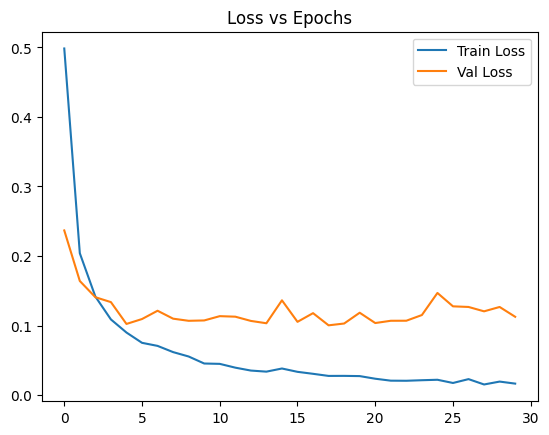

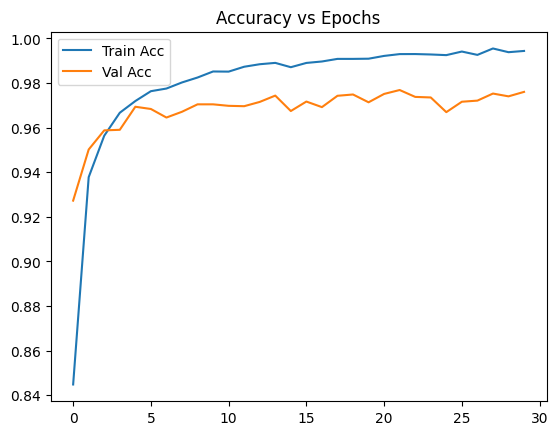

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

In [ ]:
test_loss, test_acc = evaluate(model, tst_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9754


AdamW + Dropout

In [15]:
class FCNN_Dropout(nn.Module):
    def __init__(self, p=0.3):
        super(FCNN_Dropout, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 392),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(392, 196),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(196, 98),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(98, 49),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(49, 10)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
model = FCNN_Dropout(p=0.3).to(device)
optimizer = AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()



epochs = 25

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = train(model, trn_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, vld_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1:
Train Loss: 0.7293, Train Acc: 0.7662
Val Loss: 0.2500, Val Acc: 0.9253
Epoch 2:
Train Loss: 0.3292, Train Acc: 0.9090
Val Loss: 0.2059, Val Acc: 0.9394
Epoch 3:
Train Loss: 0.2636, Train Acc: 0.9279
Val Loss: 0.1716, Val Acc: 0.9513
Epoch 4:
Train Loss: 0.2290, Train Acc: 0.9369
Val Loss: 0.1616, Val Acc: 0.9530
Epoch 5:
Train Loss: 0.2077, Train Acc: 0.9437
Val Loss: 0.1403, Val Acc: 0.9597
Epoch 6:
Train Loss: 0.1880, Train Acc: 0.9501
Val Loss: 0.1280, Val Acc: 0.9617
Epoch 7:
Train Loss: 0.1748, Train Acc: 0.9525
Val Loss: 0.1227, Val Acc: 0.9664
Epoch 8:
Train Loss: 0.1662, Train Acc: 0.9547
Val Loss: 0.1165, Val Acc: 0.9681
Epoch 9:
Train Loss: 0.1554, Train Acc: 0.9577
Val Loss: 0.1133, Val Acc: 0.9694
Epoch 10:
Train Loss: 0.1555, Train Acc: 0.9581
Val Loss: 0.1106, Val Acc: 0.9698
Epoch 11:
Train Loss: 0.1427, Train Acc: 0.9609
Val Loss: 0.1008, Val Acc: 0.9720
Epoch 12:
Train Loss: 0.1402, Train Acc: 0.9622
Val Loss: 0.1081, Val Acc: 0.9710
Epoch 13:
Train Loss: 0.1

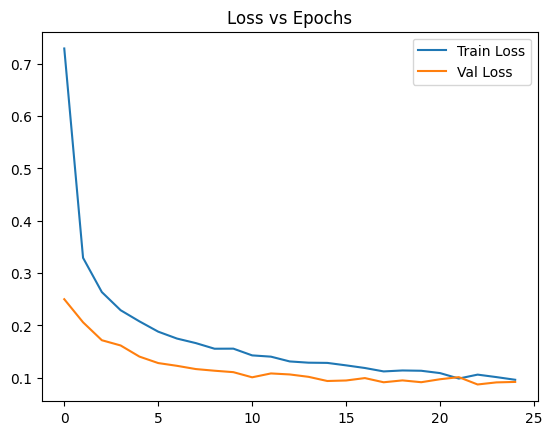

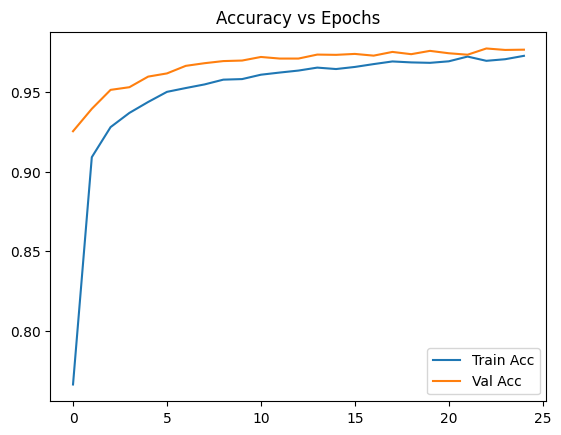

In [17]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

In [18]:
test_loss, test_acc = evaluate(model, tst_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9756


In [19]:
class FCNN_BN(nn.Module):
    def __init__(self):
        super(FCNN_BN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 392),
            nn.BatchNorm1d(392),
            nn.ReLU(),

            nn.Linear(392, 196),
            nn.BatchNorm1d(196),
            nn.ReLU(),

            nn.Linear(196, 98),
            nn.BatchNorm1d(98),
            nn.ReLU(),

            nn.Linear(98, 49),
            nn.BatchNorm1d(49),
            nn.ReLU(),

            nn.Linear(49, 10)
        )

    def forward(self, x):
        return self.model(x)

In [21]:
model = FCNN_BN().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()



epochs = 25

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = train(model, trn_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, vld_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1:
Train Loss: 0.3143, Train Acc: 0.9364
Val Loss: 0.1364, Val Acc: 0.9623
Epoch 2:
Train Loss: 0.0924, Train Acc: 0.9735
Val Loss: 0.0927, Val Acc: 0.9733
Epoch 3:
Train Loss: 0.0640, Train Acc: 0.9811
Val Loss: 0.0870, Val Acc: 0.9739
Epoch 4:
Train Loss: 0.0453, Train Acc: 0.9869
Val Loss: 0.0915, Val Acc: 0.9722
Epoch 5:
Train Loss: 0.0383, Train Acc: 0.9883
Val Loss: 0.0778, Val Acc: 0.9778
Epoch 6:
Train Loss: 0.0305, Train Acc: 0.9906
Val Loss: 0.0710, Val Acc: 0.9788
Epoch 7:
Train Loss: 0.0282, Train Acc: 0.9908
Val Loss: 0.0743, Val Acc: 0.9791
Epoch 8:
Train Loss: 0.0219, Train Acc: 0.9932
Val Loss: 0.0703, Val Acc: 0.9798
Epoch 9:
Train Loss: 0.0191, Train Acc: 0.9939
Val Loss: 0.0657, Val Acc: 0.9822
Epoch 10:
Train Loss: 0.0169, Train Acc: 0.9949
Val Loss: 0.0730, Val Acc: 0.9811
Epoch 11:
Train Loss: 0.0172, Train Acc: 0.9945
Val Loss: 0.0752, Val Acc: 0.9795
Epoch 12:
Train Loss: 0.0147, Train Acc: 0.9951
Val Loss: 0.0709, Val Acc: 0.9826
Epoch 13:
Train Loss: 0.0

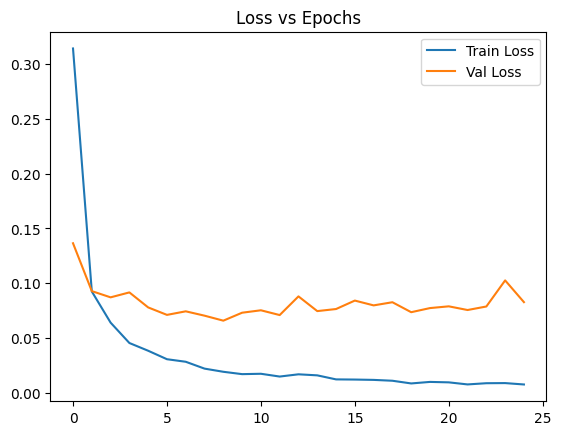

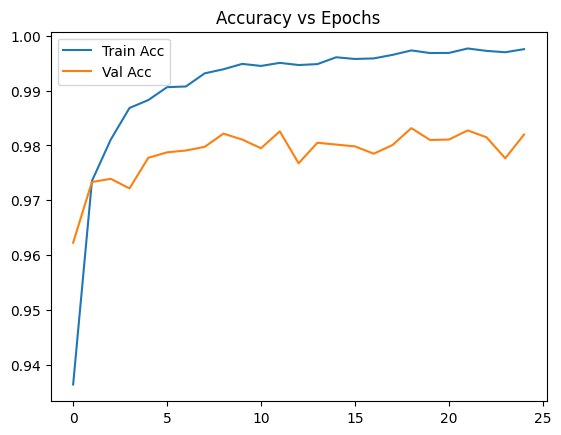

In [22]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

In [23]:
test_loss, test_acc = evaluate(model, tst_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9799
